# Data Exploration notebook

## Data Loading

First we load the prices and their log returns. 

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Switch to parent directory
os.chdir("..")
root = os.getcwd()

In [3]:
prices = pd.read_parquet(root + "/data/processed/sp500_cleaned_prices.parquet")
log_ret = pd.read_parquet(root + "/data/processed/sp500_log_returns.parquet")
simple_ret = pd.read_parquet(root + "/data/processed/sp500_simple_returns.parquet")
benchmark = pd.read_parquet(root + "/data/processed/sp500_benchmark.parquet")

## Data Quality Analysis

We verify that the preprocessing and cleaning were correctly applied to our financial data. \
To do that, we first check if any null values are still present in the time series.

In [4]:
prices.isnull().sum().sort_values(ascending=False)

A       0
ON      0
OKE     0
ODFL    0
O       0
       ..
EME     0
ELV     0
EL      0
EIX     0
ZBRA    0
Length: 429, dtype: int64

In [5]:
(prices == 0).any().sum()

0

Here no NaN values seem to be present in the data.\
We then check for abnormal log returns.\
We define log returns as:

$r_t=ln(\frac{P_t}{P_{t-1}})$

Here we consider anything above a 50% movement in prices a potential anomaly:

$r_t=ln(\frac{1.5 \times P_{t-1}}{P_{t-1}})=ln(1.5)$\
$r_t=ln(\frac{0.5 \times P_{t-1}}{P_{t-1}})=ln(0.5)$

Here note that $|ln(1.5)| < |ln(0.5)|$, so by setting $|r_t| > ln(1.5)$, we flag any period where the price moved by a factor of 1.5 or more in either direction.

In [6]:
mask = log_ret.abs() > np.log(1.5) # ~|pct_change| > 50%

extreme = (
    log_ret[mask]
    .stack()
    .reset_index()
    .rename(columns={"level_0": "date", "level_1": "ticker", 0: "log_return"})
    .sort_values("log_return")
    .reset_index(drop=True)
)
print(extreme)

         date ticker  log_return
0  2020-03-09    APA   -0.773593
1  2024-04-11     GL   -0.758010
2  2019-01-14    PCG   -0.741483
3  2020-03-09    OXY   -0.734257
4  2025-10-29   FISV   -0.580600
5  2014-05-16    TKO   -0.570082
6  2018-10-04   SMCI   -0.529694
7  2024-07-26   DXCM   -0.521858
8  2025-07-02    CNC   -0.517023
9  2025-02-13    WST   -0.481563
10 2020-03-09    OKE   -0.474096
11 2020-03-09    HAL   -0.472302
12 2020-03-09    DVN   -0.468360
13 2025-07-31   ALGN   -0.456120
14 2011-08-02   TMUS   -0.455523
15 2025-09-10   SNPS   -0.443748
16 2022-04-20   NFLX   -0.432578
17 2011-10-25   NFLX   -0.429178
18 2016-02-08    WMB   -0.427912
19 2020-03-16    MGM   -0.409684
20 2011-12-21   EXPE   -0.408806
21 2016-04-22    AMD    0.420617
22 2012-05-07   VRTX    0.440572
23 2016-07-05    DHR    0.477590
24 2013-04-19   VRTX    0.481849
25 2015-04-13   BLDR    0.516894
26 2025-08-26   SATS    0.532084
27 2019-01-24    PCG    0.557289


In [7]:
print(prices["DHR"].loc["2016-06-28":"2016-07-12"])

2016-06-28    40.368847
2016-06-29    41.187576
2016-06-30    41.553741
2016-07-01    42.096825
2016-07-04    42.096825
2016-07-05    67.867821
2016-07-06    68.053551
2016-07-07    68.121063
2016-07-08    68.256165
2016-07-11    67.597725
2016-07-12    67.817169
Name: DHR, dtype: float64


In [8]:
print(prices["EXPE"].loc["2011-12-14":"2011-12-28"])

2011-12-14    36.433651
2011-12-15    36.726494
2011-12-16    37.245640
2011-12-19    36.699867
2011-12-20    38.004398
2011-12-21    25.251760
2011-12-22    26.392574
2011-12-23    27.198391
2011-12-26    27.198391
2011-12-27    27.225550
2011-12-28    26.754732
Name: EXPE, dtype: float64


In [9]:
log_ret.loc["2016-07-05", "DHR"] = np.nan
log_ret.loc["2011-12-21", "EXPE"] = 0.0

## Return Distribution Analysis

In [10]:
def distribution_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Skewness, excess kurtosis and Jarque-Bera for each ticker (column)."""
    rows = []
    for tkr in df.columns:
        x = df[tkr].dropna().to_numpy()
        jb_stat, jb_p = stats.jarque_bera(x)
        rows.append({
            "ticker": tkr,
            "n": x.size,
            "mean": x.mean(),
            "std": x.std(),
            "skew": stats.skew(x),
            "excess_kurtosis": stats.kurtosis(x),
            "JB_stat": jb_stat,
            "JB_pvalue": jb_p,
            "normal_at_5pct": jb_p > 0.05,
        })
    return pd.DataFrame(rows).set_index("ticker")


stats_df = distribution_stats(log_ret)

print("Per-ticker distribution stats")
print(stats_df.sort_values("excess_kurtosis", ascending=False).head(10))

n_total = len(stats_df)
n_reject = (~stats_df["normal_at_5pct"]).sum()
print(f"\nTickers analysed: {n_total}")
print(f"Reject normality at 5% (JB): {n_reject} ({n_reject / n_total:.1%})")
print(f"Median excess kurtosis: {stats_df['excess_kurtosis'].median():.2f}")
print(f"Median |skew|: {stats_df['skew'].abs().median():.3f}")

Per-ticker distribution stats
           n      mean       std       skew  excess_kurtosis       JB_stat  \
ticker                                                                       
GL      4017  0.000480  0.019520 -14.545109       572.527687  5.500515e+07   
FISV    4017  0.000416  0.018000  -9.440199       281.811063  1.335216e+07   
OXY     4017 -0.000031  0.027101  -4.453889       142.500391  3.412058e+06   
PCG     4017 -0.000189  0.030861  -3.520219       138.735173  3.229838e+06   
WST     4017  0.000712  0.019394  -3.594707       103.928008  1.816474e+06   
APA     4017 -0.000263  0.032713  -3.580257        88.450804  1.318048e+06   
SNPS    4017  0.000755  0.018845  -3.333313        81.669632  1.123818e+06   
TKO     4017  0.000761  0.024732  -3.372509        79.851166  1.074833e+06   
TMUS    4017  0.000657  0.021175  -1.747069        70.567717  8.355380e+05   
VRTX    4017  0.000627  0.025280   3.321464        69.908542  8.253818e+05   

        JB_pvalue  normal_at_5pct

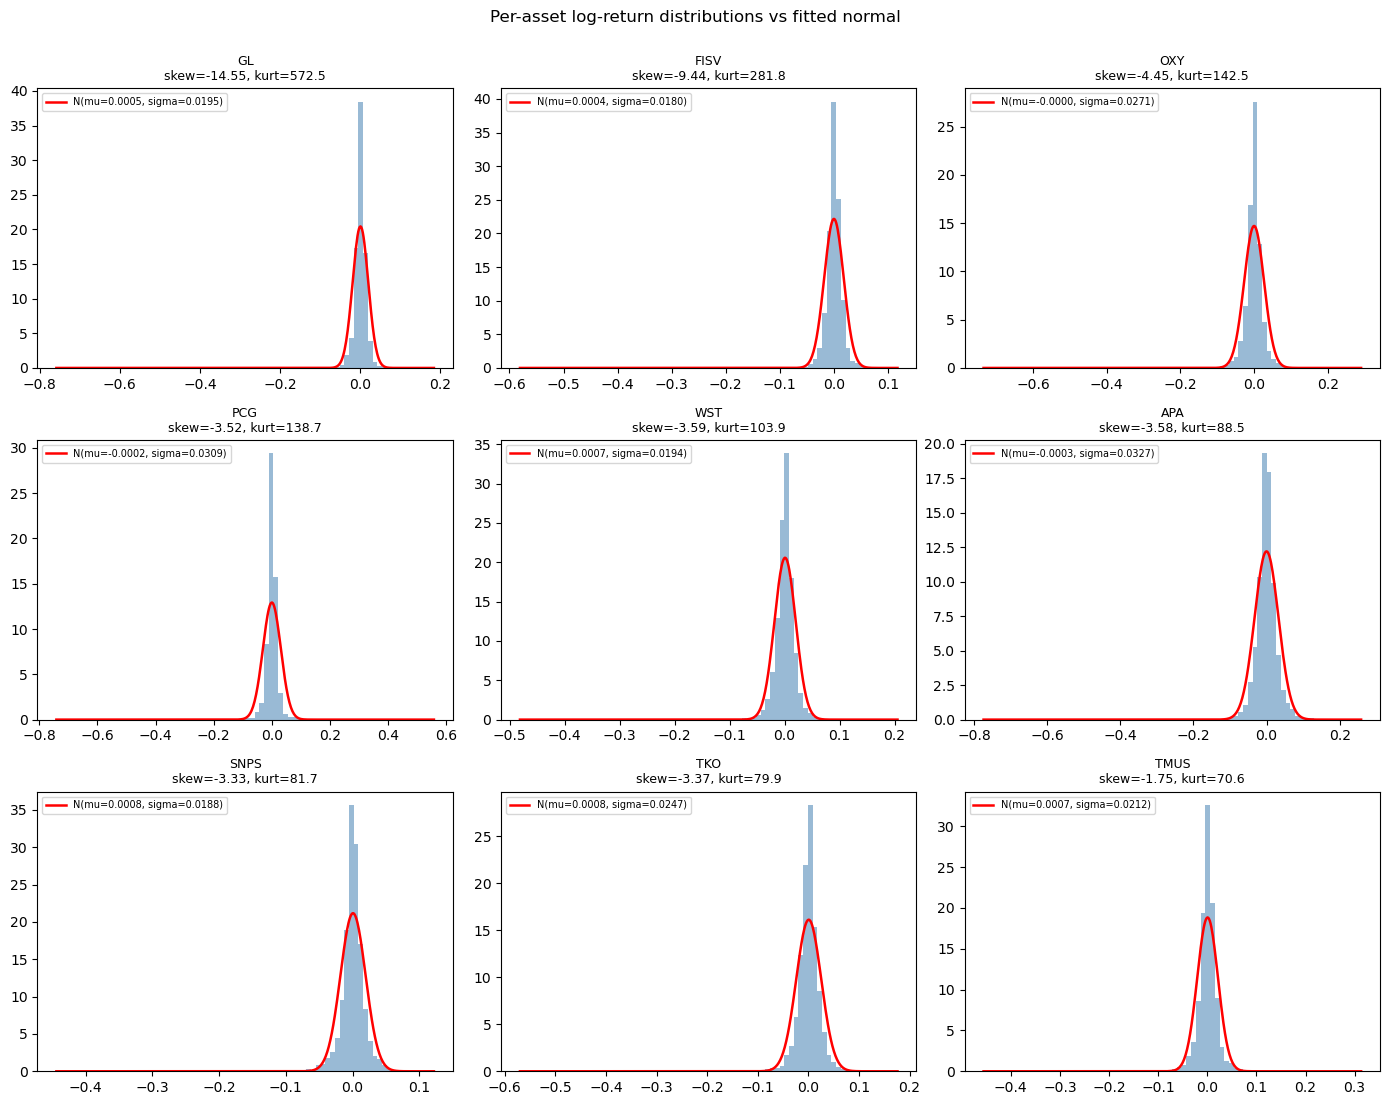

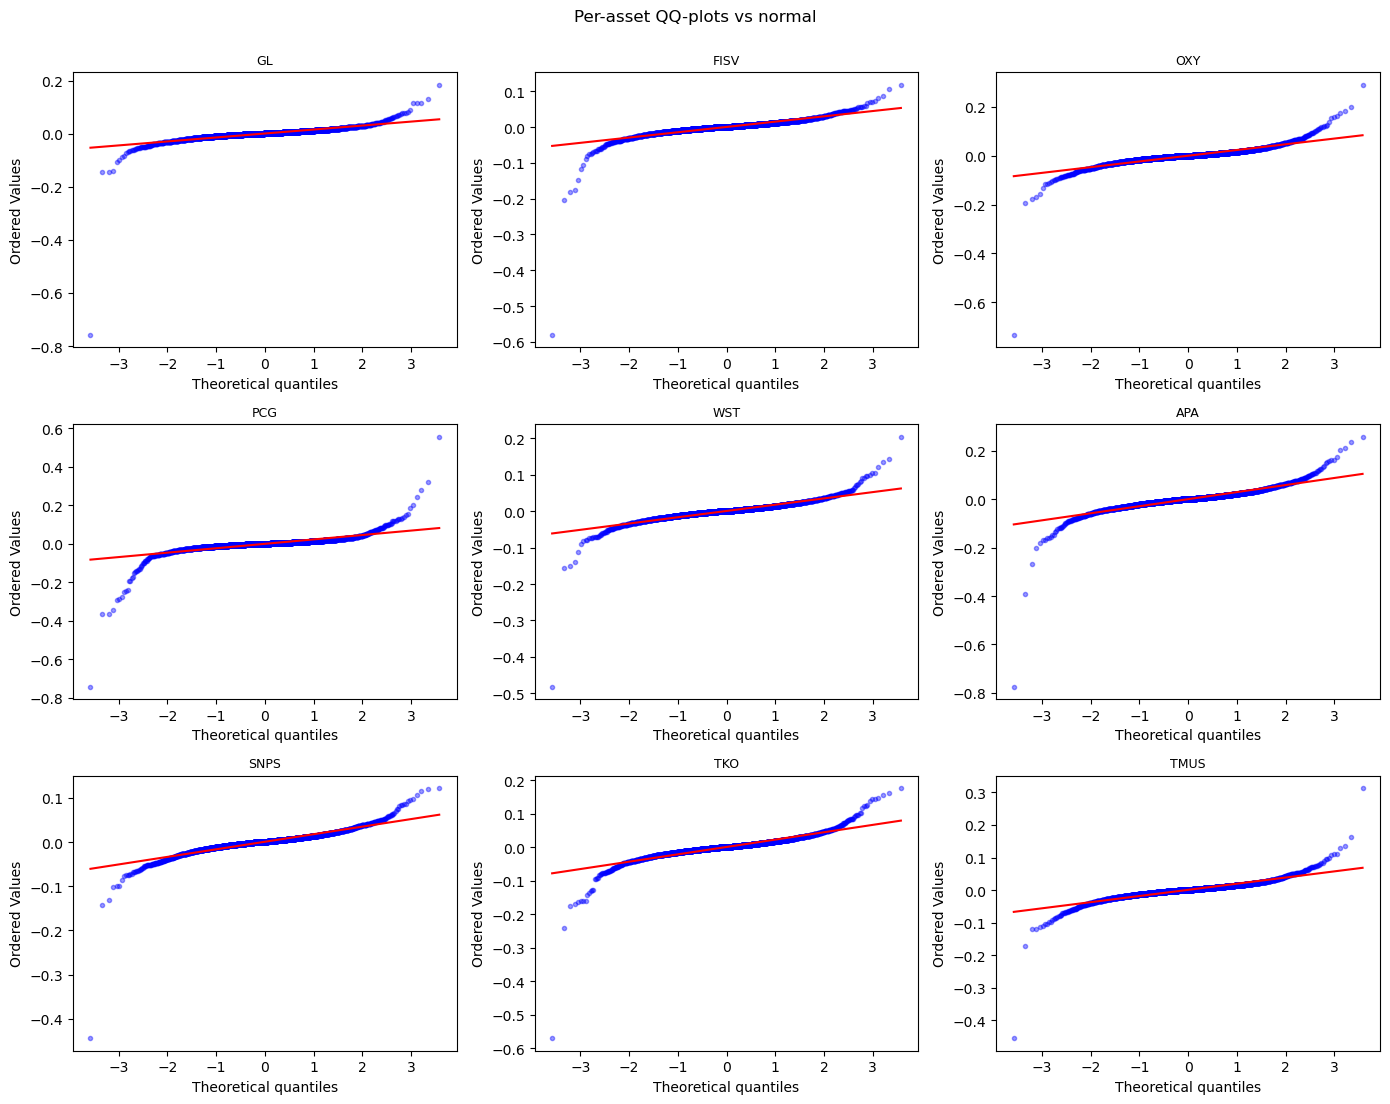

In [13]:
def plot_hist_normal(x, ax, title, bins=100):
    """Density histogram with an MLE-fitted normal pdf overlaid."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    mu, sigma = x.mean(), x.std()
    ax.hist(x, bins=bins, density=True, alpha=0.55,
            color="steelblue", edgecolor="none")
    grid = np.linspace(x.min(), x.max(), 500)
    ax.plot(grid, stats.norm.pdf(grid, mu, sigma), "r-", lw=1.8,
            label=f"N(mu={mu:.4f}, sigma={sigma:.4f})")
    ex_k = stats.kurtosis(x, fisher=True)
    sk = stats.skew(x)
    ax.set_title(f"{title}\nskew={sk:.2f}, kurt={ex_k:.1f}", fontsize=9)
    ax.legend(fontsize=7)
 
 
def plot_qq(x, ax, title):
    """QQ-plot of the data against a normal distribution."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    stats.probplot(x, dist="norm", plot=ax)
    ax.get_lines()[0].set_markersize(3)
    ax.get_lines()[0].set_alpha(0.4)
    ax.set_title(title, fontsize=9)


sample = stats_df["excess_kurtosis"].sort_values(ascending=False).head(9).index
 
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for tkr, ax in zip(sample, axes.ravel()):
    plot_hist_normal(log_ret[tkr], ax, tkr, bins=80)
fig.suptitle("Per-asset log-return distributions vs fitted normal", y=1.0)
fig.tight_layout()
plt.show()
 
# Matching QQ-plot grid for the same names
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for tkr, ax in zip(sample, axes.ravel()):
    plot_qq(log_ret[tkr], ax, tkr)
fig.suptitle("Per-asset QQ-plots vs normal", y=1.0)
fig.tight_layout()
plt.show()

## Volatility Clustering